In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import seaborn as sns
import kagglehub

C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde
C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("florianhinrichsen/nyc-taxi-data-2023-24")

PUs_df = pd.read_parquet(f"{path}\hourlyPUs2023-24WEATHER.parquet")
DOs_df = pd.read_parquet(f"{path}\hourlyDOs2023-24WEATHER.parquet")

DOs_df = DOs_df[(DOs_df["year"] >= 2023) & (DOs_df["year"] <= 2024)]

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 20
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 50

### Trip count

Trip count per month

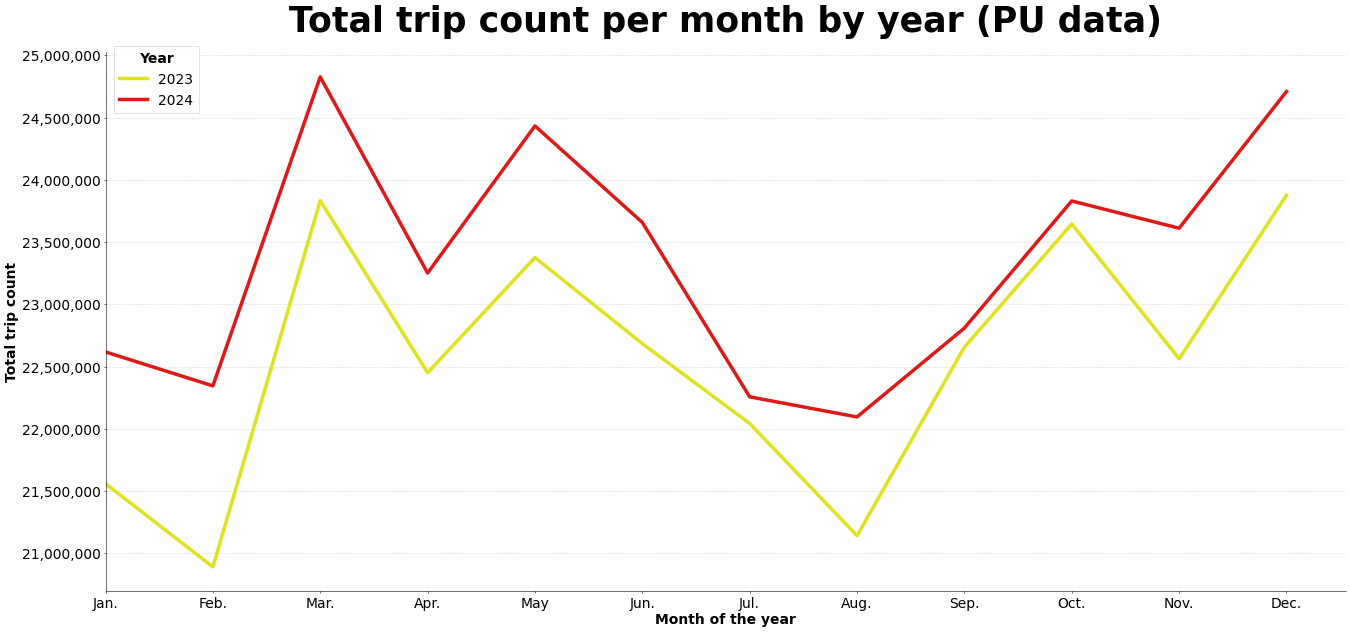

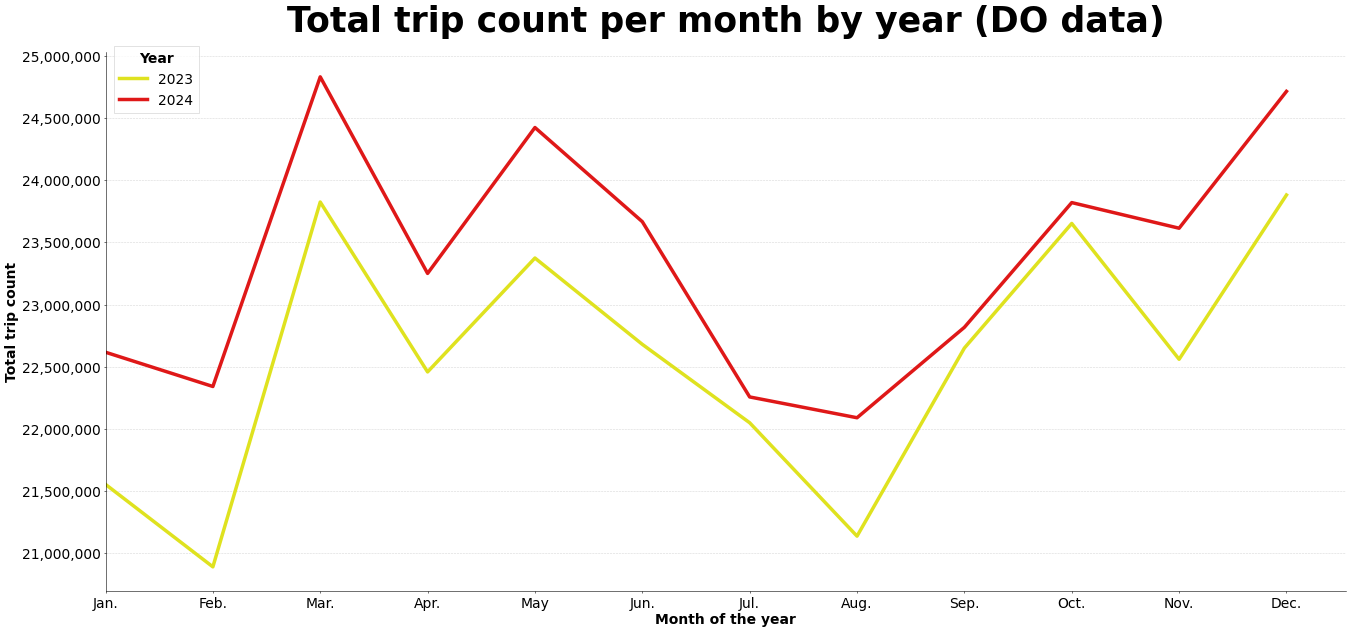

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Data Aggregation
# Group the raw hourly records by year and month to calculate the total monthly trip volumes.
# This aggregation is performed separately for Pick-Ups (PUs) and Drop-Offs (DOs).
month_PUs = PUs_df.groupby(["year", "month"])["trip_count"].sum().reset_index()
month_DOs = DOs_df.groupby(["year", "month"])["trip_count"].sum().reset_index()

# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Monthly Trip Counts
# ---------------------------------------------------------

# Initialize a wide-format figure to accommodate the 12-month timeline
fig, ax = plt.subplots(figsize=(32, 14))

# Plot the monthly trends, differentiating the 2023 and 2024 data by color
sns.lineplot(
    data=month_PUs, 
    x="month", 
    y="trip_count", 
    hue="year", 
    palette=["#DFE21F", "#DF1818"], # Yellow for 2023, Red for 2024
    linewidth=5,
    ax=ax
)

# Format the y-axis to display large trip volumes with comma separators (e.g., 1,000,000)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))     # AI generated

# Configure plot aesthetics, titles, and gridlines
plt.title("Total trip count per month by year (PU data)", fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Month of the year", fontweight="bold")
plt.ylabel("Total trip count", fontweight="bold")

# Map numeric month values (1-12) to standard string abbreviations
plt.xticks(
    range(1, 13),
    labels=["Jan.", "Feb.", "Mar.", "Apr.", "May", "Jun.", "Jul.", "Aug.", "Sep.", "Oct.", "Nov.", "Dec."]
)
plt.xlim(left=1) # Ensure the plot starts strictly at January

# Extract existing legend handles to reposition the legend box outside the primary data area
handles, labels = ax.get_legend_handles_labels()        # AI generated
ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight": "bold"},
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False
)

# Export the high-resolution figure (forward slashes ensure cross-platform OS compatibility)
#plt.savefig("Plots/TimeSeries/TripCount/PUsTripCountMonthly.png", dpi=300)
plt.show()


# ---------------------------------------------------------
# 3. Visualization: Drop-Off (DO) Monthly Trip Counts
# ---------------------------------------------------------

# Re-initialize the figure dimensions for the Drop-Off plot
fig, ax = plt.subplots(figsize=(32, 14))

# Plot the monthly drop-off trends using the identical color mapping
sns.lineplot(
    data=month_DOs, 
    x="month", 
    y="trip_count", 
    hue="year", 
    palette=["#DFE21F", "#DF1818"],
    linewidth=5,
    ax=ax
)

# Apply identical formatting rules to ensure visual consistency between the PU and DO plots
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))     # AI generated

plt.title("Total trip count per month by year (DO data)", fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Month of the year", fontweight="bold")
plt.ylabel("Total trip count", fontweight="bold")

plt.xticks(
    range(1, 13),
    labels=["Jan.", "Feb.", "Mar.", "Apr.", "May", "Jun.", "Jul.", "Aug.", "Sep.", "Oct.", "Nov.", "Dec."]
)
plt.xlim(left=1)

# Reposition the legend
handles, labels = ax.get_legend_handles_labels()            # AI generated
ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight": "bold"},
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False
)

#plt.savefig("Plots/TimeSeries/TripCount/DOsTripCountMonthly.png", dpi=300)
plt.show()

Trip count over a 7-day rolling average window

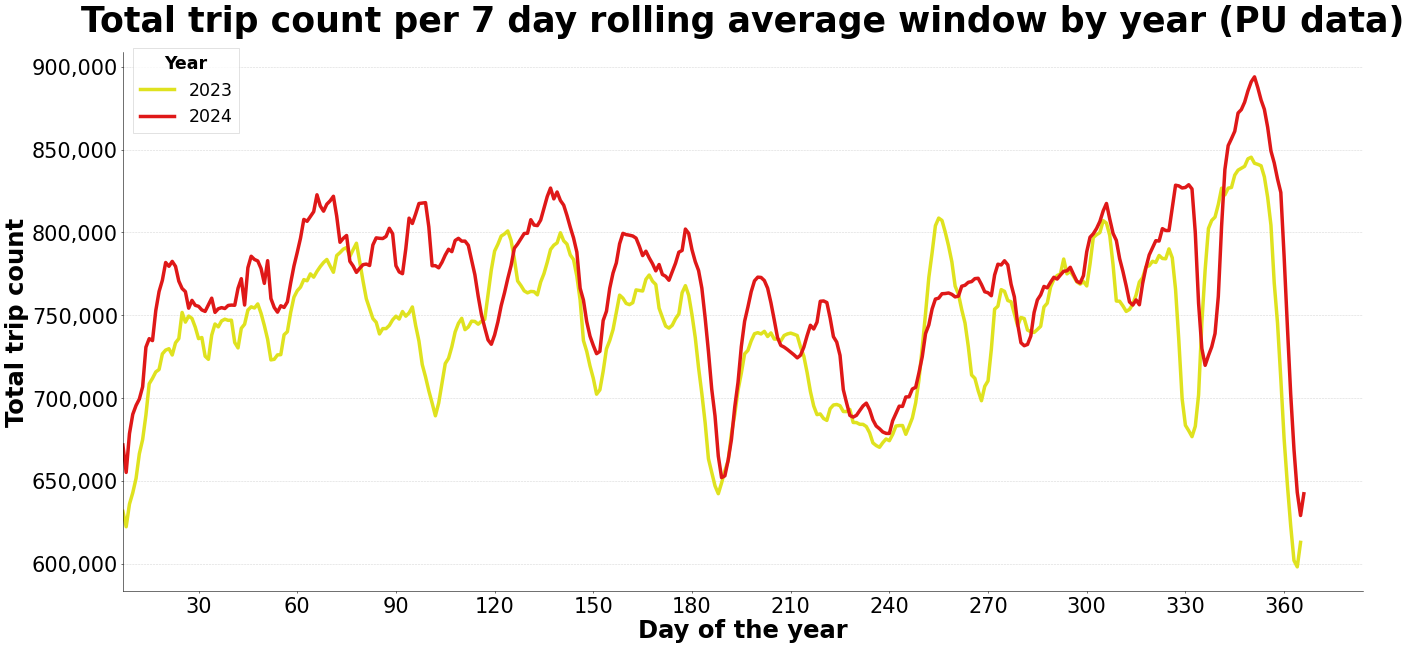

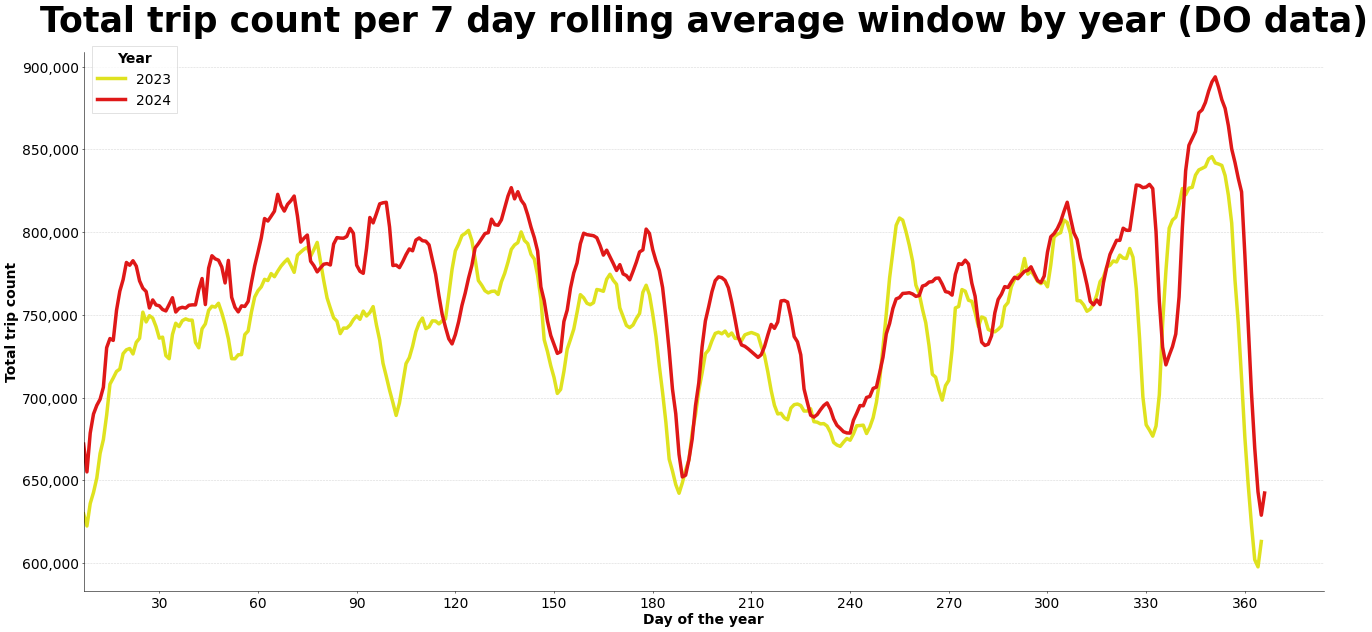

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as ticker

# ---------------------------------------------------------
# 1. Temporal Aggregation (Daily Volumes)
# ---------------------------------------------------------
# Group the hourly records by calendar date to calculate the total daily trip volumes.
# This flattens the intra-day variance (e.g., morning vs. evening rush hours).
daily_PUs = PUs_df.groupby(PUs_df["PUhour"].dt.date)["trip_count"].sum().reset_index()
daily_DOs = DOs_df.groupby(DOs_df["DOhour"].dt.date)["trip_count"].sum().reset_index()

# The .date extraction returns standard Python date objects; 
# reconvert them to pandas datetime objects for vectorized temporal extraction.
daily_PUs["PUhour"] = pd.to_datetime(daily_PUs["PUhour"])
daily_DOs["DOhour"] = pd.to_datetime(daily_DOs["DOhour"])

# ---------------------------------------------------------
# 2. Feature Extraction (Year & Day of Year)
# ---------------------------------------------------------
# Extract the year and the numerical day of the year (1-365) to allow 
# the 2023 and 2024 timelines to be overlaid on the exact same x-axis.
daily_PUs["year"] = daily_PUs["PUhour"].dt.year
daily_DOs["year"] = daily_DOs["DOhour"].dt.year

daily_PUs["DayOfYear"] = daily_PUs["PUhour"].dt.dayofyear
daily_DOs["DayOfYear"] = daily_DOs["DOhour"].dt.dayofyear

# ---------------------------------------------------------
# 3. Moving Average Smoothing  (AI generated)
# ---------------------------------------------------------
# Apply a 7-day rolling average grouped by year. 
# This critical step filters out the high-frequency noise of the weekly cycle 
# (e.g., weekend demand peaks) to isolate the macro-level seasonal trajectory.
daily_PUs["7dayAVG"] = daily_PUs.groupby(daily_PUs["PUhour"].dt.year)["trip_count"].transform(
    lambda x: x.rolling(window=7).mean()
)

daily_DOs["7dayAVG"] = daily_DOs.groupby(daily_DOs["DOhour"].dt.year)["trip_count"].transform(
    lambda x: x.rolling(window=7).mean()
)


# ---------------------------------------------------------
# 4. Visualization: Pick-Up (PU) 7-Day Rolling Average
# ---------------------------------------------------------
plt.figure(figsize=(32,14))

# Plot the smoothed rolling average, color-coded by year
ax = sns.lineplot(
    data=daily_PUs, 
    x="DayOfYear", 
    y="7dayAVG", 
    hue="year", 
    palette=['#DFE21F', '#DF1818'], # Yellow for 2023, Red for 2024
    linewidth=5
)

# Format the y-axis with comma separators for readability
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))     # AI generated

# Configure plot aesthetics, titles, and gridlines
plt.title("Total trip count per 7 day rolling average window by year (PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold", fontsize=35)
plt.ylabel("Total trip count", fontweight="bold", fontsize=35)

# Set x-ticks at roughly monthly intervals (every 30 days)
plt.xticks(range(0, 366, 30), fontsize=30)
plt.yticks(fontsize=30)
plt.xlim(left=7) # Start the plot at day 7 to hide the initial NaN values from the rolling window

# Configure and reposition the legend
handles, labels = ax.get_legend_handles_labels()        # AI generated
ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight":"bold", "size":25},
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False,
    fontsize=25
)

#plt.savefig("Plots/TimeSeries/TripCount/PUsTripCount7DayAVG.pdf", dpi=300, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------
# 5. Visualization: Drop-Off (DO) 7-Day Rolling Average
# ---------------------------------------------------------
plt.figure(figsize=(32,14))

# Plot the smoothed rolling average for Drop-Offs
ax = sns.lineplot(
    data=daily_DOs, 
    x="DayOfYear", 
    y="7dayAVG", 
    hue="year", 
    palette=['#DFE21F', '#DF1818'], 
    linewidth=5
)

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))     # AI generated

plt.title("Total trip count per 7 day rolling average window by year (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Total trip count", fontweight="bold")

plt.xticks(range(0, 366, 30))
plt.xlim(left=7)

handles, labels = ax.get_legend_handles_labels()            # AI generated
ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight":"bold"},
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False
)


#plt.savefig("Plots/TimeSeries/TripCount/DOsTripCount7DayAVG.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Trip distance

Trip distance per month

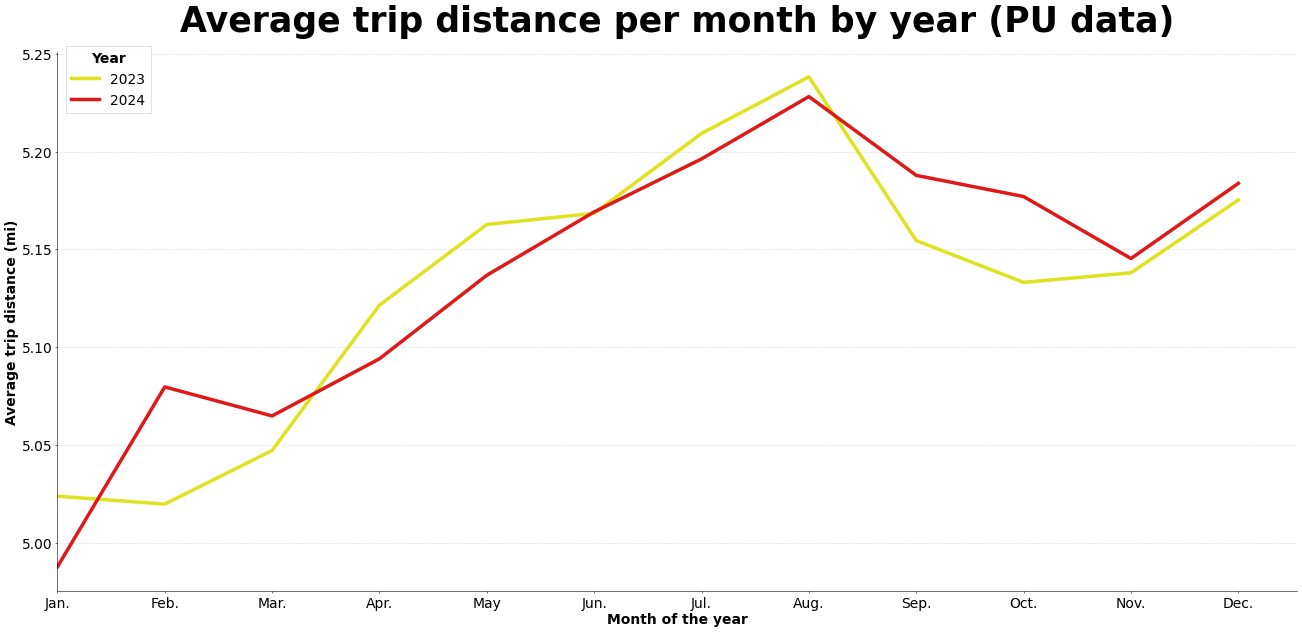

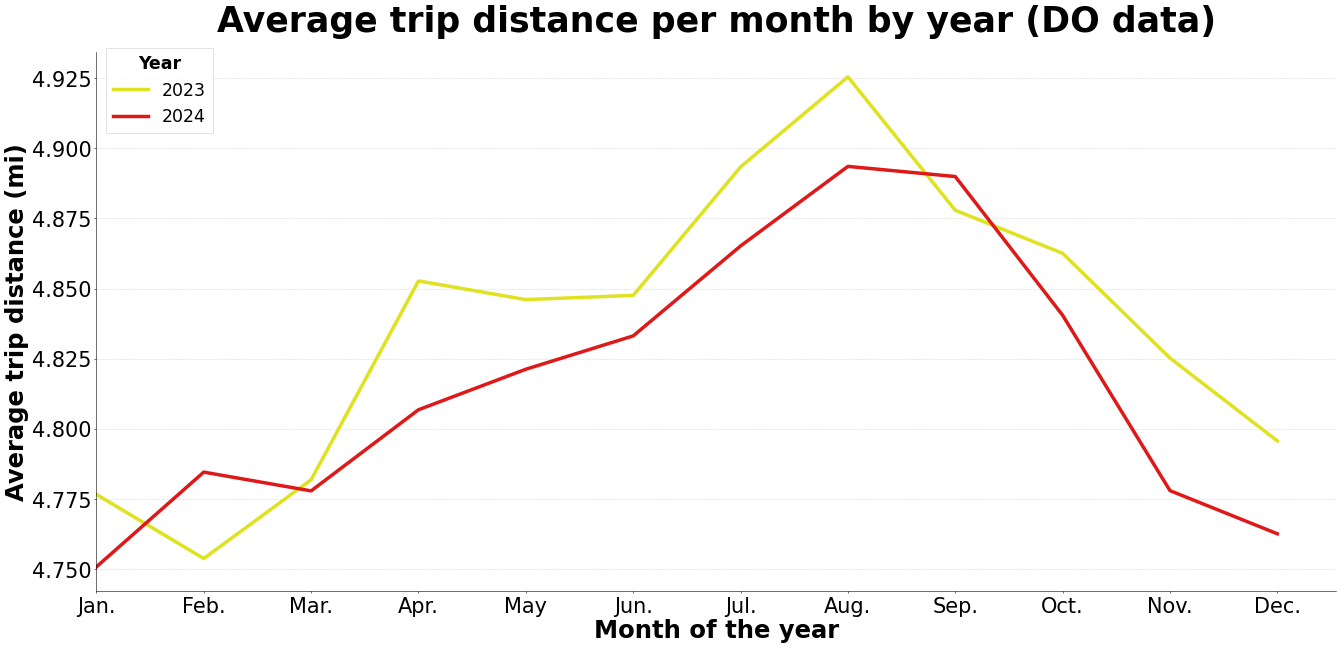

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as ticker

# ---------------------------------------------------------
# 1. Temporal Aggregation (Monthly Averages)
# ---------------------------------------------------------
# Group the dataset by year and month to calculate the mean trip distance.
# This aggregation highlights macro-level seasonal variations in passenger 
# travel behavior (e.g., identifying if trips are shorter during winter).
month_PUs = PUs_df.groupby(["year", "month"])["trip_distance"].mean().reset_index()
month_DOs = DOs_df.groupby(["year", "month"])["trip_distance"].mean().reset_index()


# ---------------------------------------------------------
# 2. Visualization: Pick-Up (PU) Average Trip Distance
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(32, 14))

# Plot the monthly mean distances, comparing 2023 and 2024
sns.lineplot(
    data=month_PUs, 
    x="month", 
    y="trip_distance", 
    hue="year", 
    palette=['#DFE21F', '#DF1818'], # Yellow for 2023, Red for 2024
    linewidth=5,
    ax=ax
)

# Configure plot aesthetics, titles, and gridlines
plt.title("Average trip distance per month by year (PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Month of the year", fontweight="bold")
plt.ylabel("Average trip distance (mi)", fontweight="bold")

# Map the numeric month values (1-12) to standard string abbreviations
plt.xticks(
    range(1, 13),
    labels=["Jan.", "Feb.", "Mar.", "Apr.", "May", "Jun.", "Jul.", "Aug.", "Sep.", "Oct.", "Nov.", "Dec."]
)
plt.xlim(left=1)

# Extract and reposition the legend outside the main plot area
handles, labels = ax.get_legend_handles_labels()        # AI generated
ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight": "bold"},
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False
)

# Export the figure (forward slashes used for cross-platform stability)
#plt.savefig("Plots/TimeSeries/TripDistance/PUsTripDistanceMonthly.png", dpi=300)
plt.show()


# ---------------------------------------------------------
# 3. Visualization: Drop-Off (DO) Average Trip Distance
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(32, 14))

sns.lineplot(
    data=month_DOs, 
    x="month", 
    y="trip_distance", 
    hue="year", 
    palette=['#DFE21F', '#DF1818'],
    linewidth=5,
    ax=ax
)

plt.title("Average trip distance per month by year (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Note: Font sizes for labels and ticks are explicitly increased here 
# to optimize readability for presentation or poster formats.
plt.xlabel("Month of the year", fontweight="bold", fontsize=35)
plt.ylabel("Average trip distance (mi)", fontweight="bold", fontsize=35)
plt.xticks(
    range(1, 13),
    labels=["Jan.", "Feb.", "Mar.", "Apr.", "May", "Jun.", "Jul.", "Aug.", "Sep.", "Oct.", "Nov.", "Dec."], 
    fontsize=30
)
plt.yticks(fontsize=30)
plt.xlim(left=1)

handles, labels = ax.get_legend_handles_labels()            # AI generated
ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight": "bold", "size": 25},
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False,
    fontsize=25
)

# Export as PDF (vector format) with tight bounding box to prevent cutoffs
#plt.savefig("Plots/TimeSeries/TripDistance/DOsTripDistanceMonthly.pdf", dpi=300, bbox_inches="tight")
plt.show()

Trip distance over a 7-day rolling average window

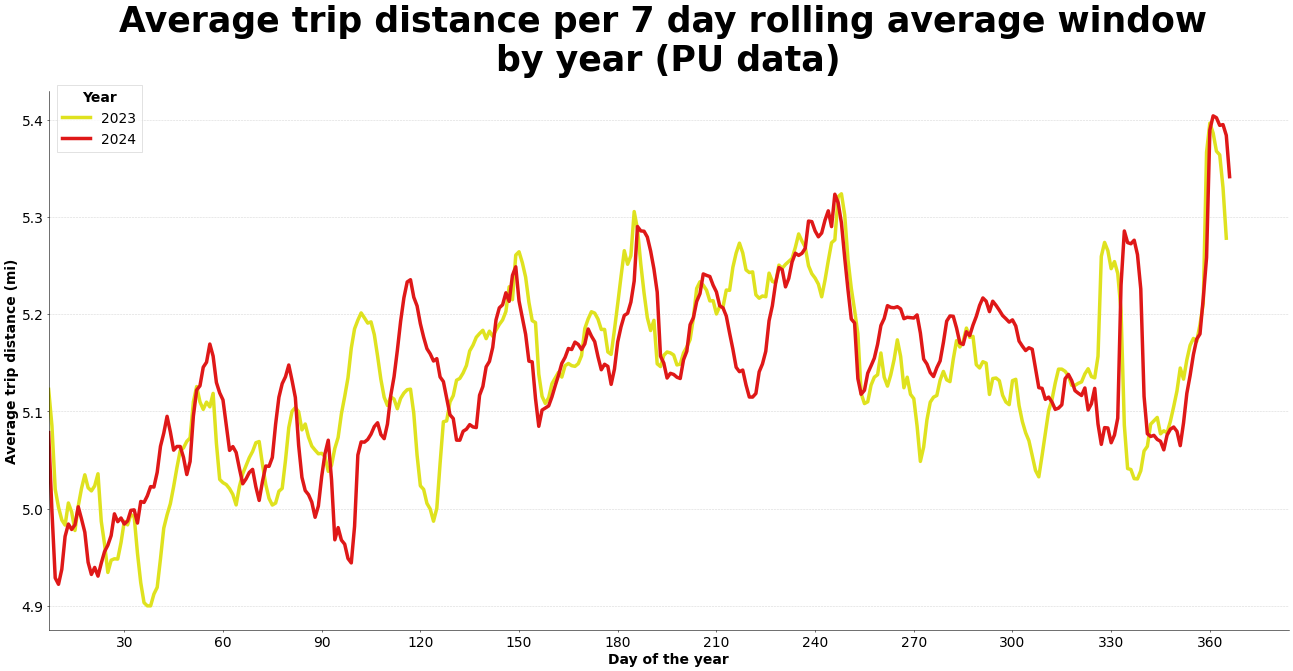

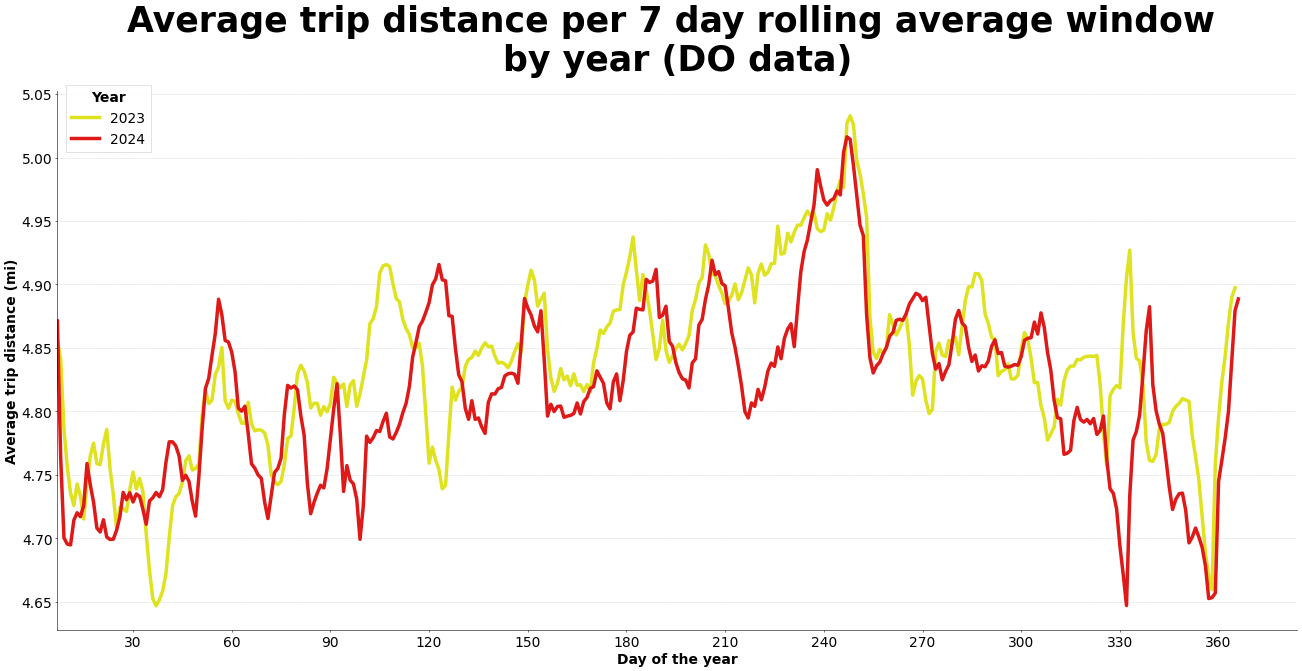

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as ticker

# ---------------------------------------------------------
# 1. Temporal Aggregation (Daily Averages)
# ---------------------------------------------------------
# Group the dataset by calendar date to calculate the mean trip distance per day.
# This flattens the variance between individual trips to establish a daily baseline.
daily_PUs = PUs_df.groupby(PUs_df["PUhour"].dt.date)["trip_distance"].mean().reset_index()
daily_DOs = DOs_df.groupby(DOs_df["DOhour"].dt.date)["trip_distance"].mean().reset_index()

# Reconvert the extracted dates back into pandas datetime objects 
# to enable vectorized temporal operations in the next step.
daily_PUs["PUhour"] = pd.to_datetime(daily_PUs["PUhour"])
daily_DOs["DOhour"] = pd.to_datetime(daily_DOs["DOhour"])

# ---------------------------------------------------------
# 2. Feature Extraction (Year & Day of Year)
# ---------------------------------------------------------
# Extract the year and the specific day of the year (1-365).
# Using the Day of Year allows us to plot both 2023 and 2024 overlapping 
# on the exact same x-axis for direct year-over-year comparison.
daily_PUs["year"] = daily_PUs["PUhour"].dt.year
daily_DOs["year"] = daily_DOs["DOhour"].dt.year

daily_PUs["DayOfYear"] = daily_PUs["PUhour"].dt.dayofyear
daily_DOs["DayOfYear"] = daily_DOs["DOhour"].dt.dayofyear

# ---------------------------------------------------------
# 3. Moving Average Smoothing  (AI generated)
# ---------------------------------------------------------
# Apply a 7-day rolling average to the daily mean distances, grouped by year.
# This smooths out high-frequency weekly volatility (e.g., people taking longer 
# trips on weekends) to reveal the broader, underlying seasonal trajectory.
daily_PUs["7dayAVG"] = daily_PUs.groupby(daily_PUs["PUhour"].dt.year)["trip_distance"].transform(
    lambda x: x.rolling(window=7).mean()
)

daily_DOs["7dayAVG"] = daily_DOs.groupby(daily_DOs["DOhour"].dt.year)["trip_distance"].transform(
    lambda x: x.rolling(window=7).mean()
)


# ---------------------------------------------------------
# 4. Visualization: Pick-Up (PU) 7-Day Rolling Average
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Plot the smoothed rolling average, differentiating the years by color
ax = sns.lineplot(
    data=daily_PUs, 
    x="DayOfYear", 
    y="7dayAVG", 
    hue="year", 
    palette=['#DFE21F', '#DF1818'], # Yellow for 2023, Red for 2024
    linewidth=5
)

# Configure plot aesthetics, titles, and gridlines
plt.title("Average trip distance per 7 day rolling average window \nby year (PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Average trip distance (mi)", fontweight="bold")

# Place x-ticks at roughly monthly intervals (every 30 days)
plt.xticks(range(0, 366, 30))
# Start the plot at day 7 to hide the initial NaN values generated by the rolling window
plt.xlim(left=7)

# Extract and reposition the legend to the top left, outside the data trajectory
handles, labels = ax.get_legend_handles_labels()            # AI generated
ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight": "bold"},
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False
)

# Export as a high-resolution PNG
#plt.savefig("Plots/TimeSeries/TripDistance/PUsTripDistance7DayAVG.png", dpi=300)
plt.show()


# ---------------------------------------------------------
# 5. Visualization: Drop-Off (DO) 7-Day Rolling Average
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

# Plot the smoothed rolling average for Drop-Offs
ax = sns.lineplot(
    data=daily_DOs, 
    x="DayOfYear", 
    y="7dayAVG", 
    hue="year", 
    palette=['#DFE21F', '#DF1818'], 
    linewidth=5
)

plt.title("Average trip distance per 7 day rolling average window \nby year (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Average trip distance (mi)", fontweight="bold")

plt.xticks(range(0, 366, 30))
plt.xlim(left=7)

handles, labels = ax.get_legend_handles_labels()            # AI generated
ax.legend(
    handles=handles,
    labels=labels,
    title="Year",
    title_fontproperties={"weight": "bold"},
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False
)

#plt.savefig("Plots/TimeSeries/TripDistance/DOsTripDistance7DayAVG.png", dpi=300)
plt.show()

### Amounts paid

Amounts paid by month

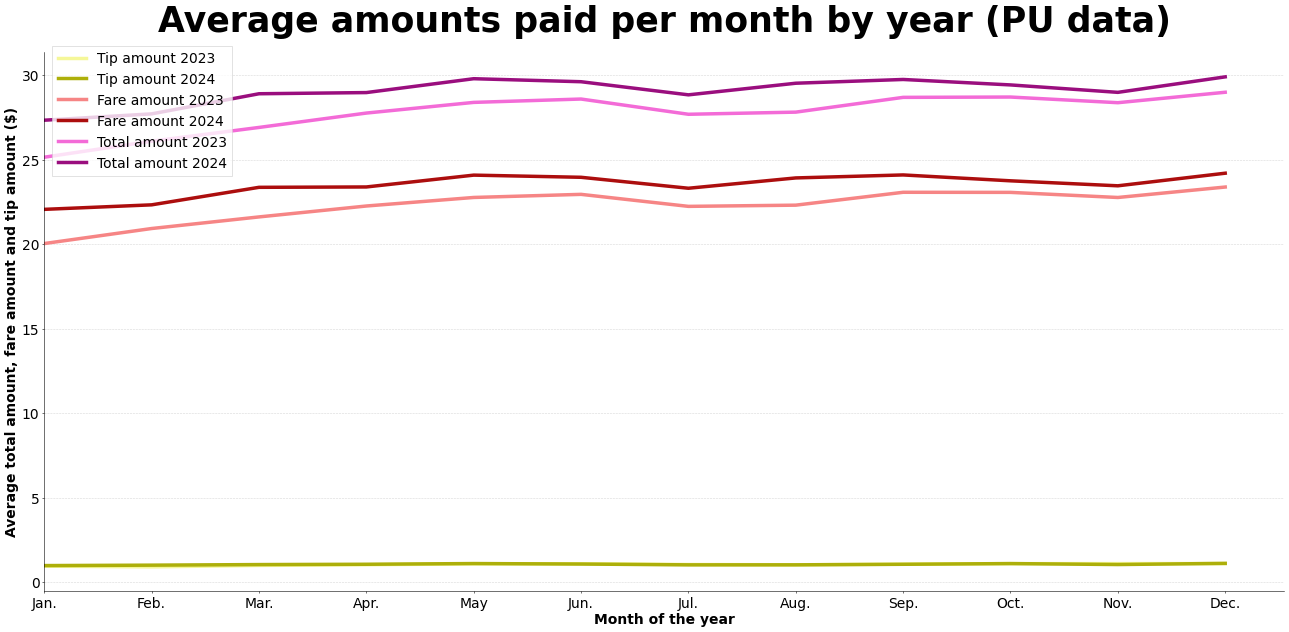

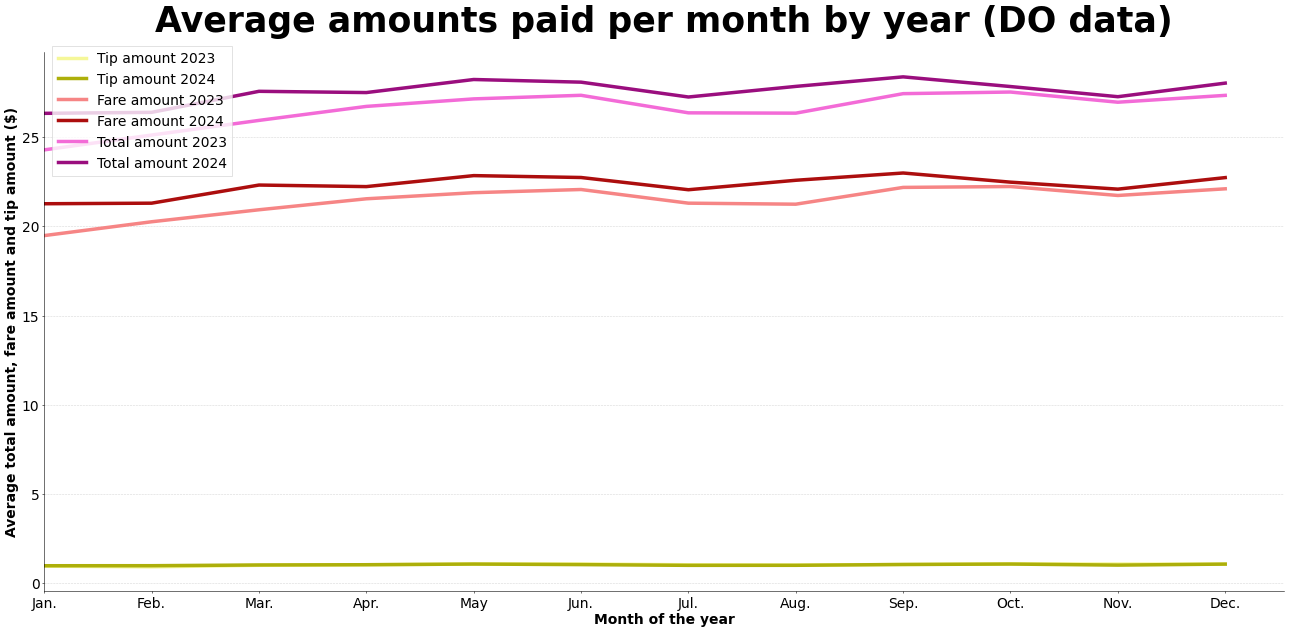

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. Temporal Formatting & Financial Aggregation
# ---------------------------------------------------------
# Ensure timestamp columns are strictly typed as pandas datetime objects
PUs_df["PUhour"] = pd.to_datetime(PUs_df["PUhour"])
DOs_df["DOhour"] = pd.to_datetime(DOs_df["DOhour"])

# Group by year and month to calculate the average values for the primary financial metrics.
# This establishes the macro-level seasonal trends in passenger payment behavior.
# (AI generated)
monthly_amounts_PUs = PUs_df.groupby(["year", "month"])[
    ["tip_amount", "fare_amount", "total_amount"]
].mean().reset_index()

monthly_amounts_DOs = DOs_df.groupby(["year", "month"])[
    ["tip_amount", "fare_amount", "total_amount"]
].mean().reset_index()

# ---------------------------------------------------------
# 2. Data Reshaping for Multi-variable Plotting
# ---------------------------------------------------------
# Transform the aggregated data from wide format to long format.
# This restructuring is necessary for Seaborn to map multiple distinct metrics 
# to a single axis using the 'hue' parameter.
# (AI generated)
melted_PUs = monthly_amounts_PUs.melt(
    id_vars=["year", "month"],
    value_vars=["tip_amount", "fare_amount", "total_amount"],
    var_name="metric",
    value_name="amount"
)

# Concatenate the metric name and year to create a unique identifier for each line
# (AI generated)
melted_PUs["metric_year"] = melted_PUs["metric"] + melted_PUs["year"].astype(str)

melted_DOs = monthly_amounts_DOs.melt(
    id_vars=["year", "month"],
    value_vars=["tip_amount", "fare_amount", "total_amount"],
    var_name="metric",
    value_name="amount"
)

melted_DOs["metric_year"] = melted_DOs["metric"] + melted_DOs["year"].astype(str)

# ---------------------------------------------------------
# 3. Visualization Configuration
# ---------------------------------------------------------
# Define a custom color palette associating lighter shades with 2023 
# and corresponding darker shades with 2024 for visual continuity.
palette = {
    "tip_amount2023": "#F5F799",
    "tip_amount2024": "#ADAF0A",
    "fare_amount2023": "#F68585",
    "fare_amount2024": "#AC0E0E",
    "total_amount2023": "#F36BD7",
    "total_amount2024": "#9A0E7E"
}

# ---------------------------------------------------------
# 4. Visualization: Pick-Up (PU) Financial Metrics
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

ax = sns.lineplot(
    data=melted_PUs,
    x="month",
    y="amount",
    hue="metric_year",
    markers=True,
    linewidth=5,
    palette=palette
)

plt.title("Average amounts paid per month by year (PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Month of the year", fontweight="bold")
plt.ylabel("Average total amount, fare amount and tip amount ($)", fontweight="bold")

plt.xticks(
    range(1, 13),
    labels=["Jan.", "Feb.", "Mar.", "Apr.", "May", "Jun.", "Jul.", "Aug.", "Sep.", "Oct.", "Nov.", "Dec."]
)
plt.xlim(left=1)

# Extract handles and overwrite the default legend labels for cleaner presentation
handles, labels = ax.get_legend_handles_labels()        # AI generated
ax.legend(
    handles=handles,
    labels=[
        "Tip amount 2023", "Tip amount 2024", 
        "Fare amount 2023", "Fare amount 2024", 
        "Total amount 2023", "Total amount 2024"
    ],
    title="",
    title_fontproperties={"weight": "bold"},
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False
)

#plt.savefig("Plots/TimeSeries/Amounts/PUsAmountsMonthly.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 5. Visualization: Drop-Off (DO) Financial Metrics
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

ax = sns.lineplot(
    data=melted_DOs,
    x="month",
    y="amount",
    hue="metric_year",
    markers=True,
    linewidth=5,
    palette=palette
)

plt.title("Average amounts paid per month by year (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Month of the year", fontweight="bold")
plt.ylabel("Average total amount, fare amount and tip amount ($)", fontweight="bold")

plt.xticks(
    range(1, 13),
    labels=["Jan.", "Feb.", "Mar.", "Apr.", "May", "Jun.", "Jul.", "Aug.", "Sep.", "Oct.", "Nov.", "Dec."]
)
plt.xlim(left=1)

handles, labels = ax.get_legend_handles_labels()        # AI generated
ax.legend(
    handles=handles,
    labels=[
        "Tip amount 2023", "Tip amount 2024", 
        "Fare amount 2023", "Fare amount 2024", 
        "Total amount 2023", "Total amount 2024"
    ],
    title="",
    title_fontproperties={"weight": "bold"},
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False
)

#plt.savefig("Plots/TimeSeries/Amounts/DOsAmountsMonthly.png", dpi=300)
plt.show()

Amounts paid over a 7-day rolling average window

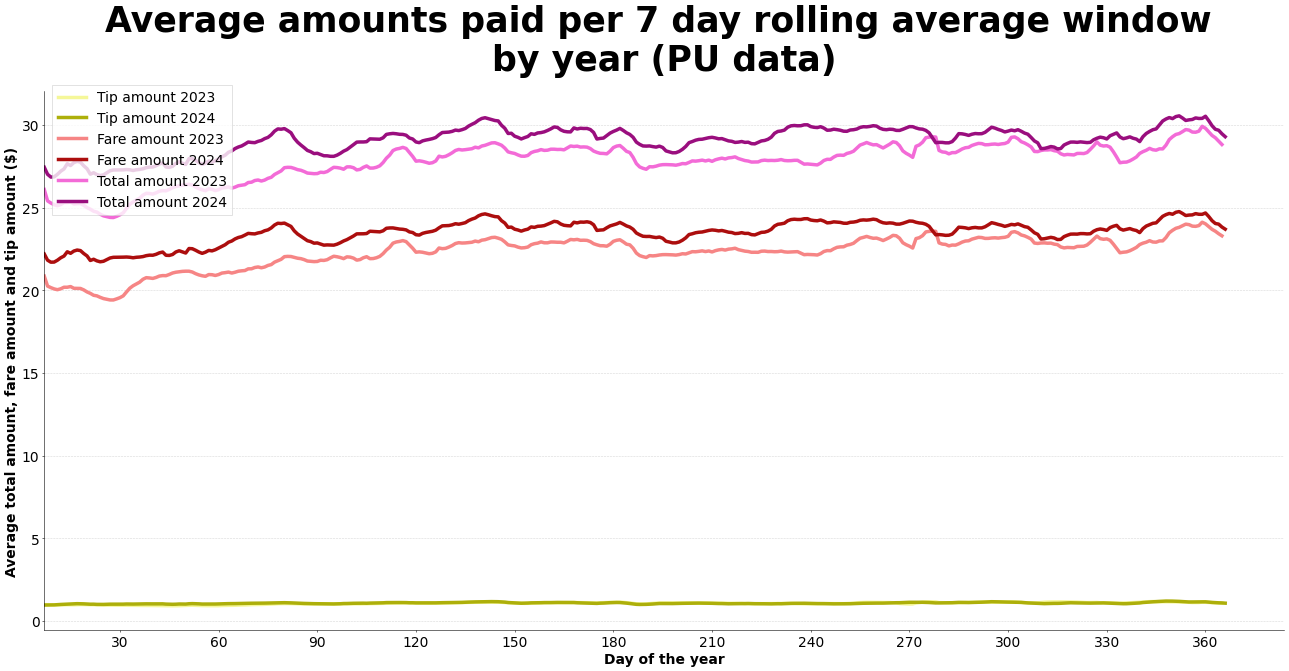

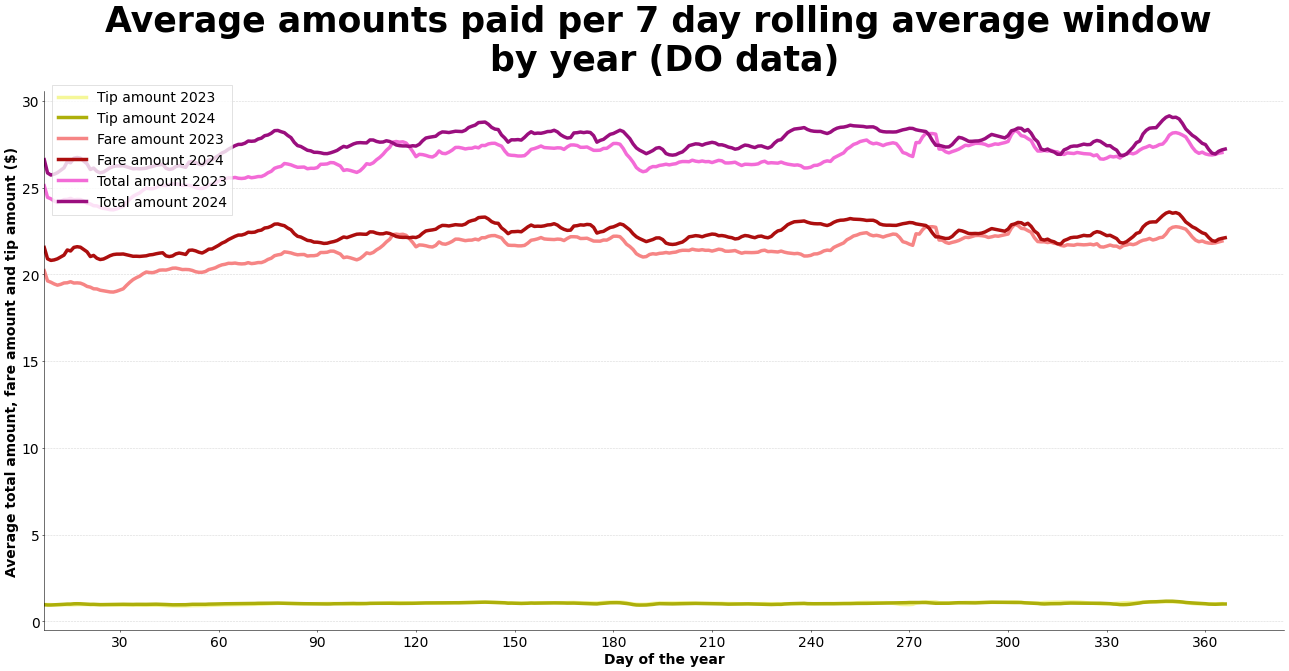

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. Temporal Aggregation (Daily Financial Averages)
# ---------------------------------------------------------
# Ensure columns are datetime objects, then group by the calendar date 
# to calculate the mean daily values for the primary financial metrics.
PUs_df["PUhour"] = pd.to_datetime(PUs_df["PUhour"])
DOs_df["DOhour"] = pd.to_datetime(DOs_df["DOhour"])

# AI generated:
daily_amounts_PUs = PUs_df.groupby(PUs_df["PUhour"].dt.date)[
    ["tip_amount", "fare_amount", "total_amount"]
].mean().reset_index()
# AI generated:
daily_amounts_DOs = DOs_df.groupby(DOs_df["DOhour"].dt.date)[
    ["tip_amount", "fare_amount", "total_amount"]
].mean().reset_index()

# Reconvert the grouped dates back to datetime objects
daily_amounts_PUs["PUhour"] = pd.to_datetime(daily_amounts_PUs["PUhour"])
daily_amounts_DOs["DOhour"] = pd.to_datetime(daily_amounts_DOs["DOhour"])

# ---------------------------------------------------------
# 2. Feature Extraction (Year & Day of Year)
# ---------------------------------------------------------
# Extract the year and day of the year (1-365) to map the multi-year 
# financial data onto a single overlaid 12-month x-axis.
daily_amounts_PUs["year"] = daily_amounts_PUs["PUhour"].dt.year
daily_amounts_PUs["DayOfYear"] = daily_amounts_PUs["PUhour"].dt.dayofyear

daily_amounts_DOs["year"] = daily_amounts_DOs["DOhour"].dt.year
daily_amounts_DOs["DayOfYear"] = daily_amounts_DOs["DOhour"].dt.dayofyear

# ---------------------------------------------------------
# 3. Data Reshaping (Wide to Long Format)
# ---------------------------------------------------------
# Melt the dataframes to consolidate the three financial metrics into a single 
# column. This structure allows Seaborn to plot all metrics simultaneously.
# (AI generated)
melted_PUs = daily_amounts_PUs.melt(
    id_vars=["PUhour", "year", "DayOfYear"],
    value_vars=["tip_amount", "fare_amount", "total_amount"],
    var_name="metric",
    value_name="amount"
)

melted_PUs["metric_year"] = melted_PUs["metric"] + melted_PUs["year"].astype(str)

melted_DOs = daily_amounts_DOs.melt(
    id_vars=["DOhour", "year", "DayOfYear"],
    value_vars=["tip_amount", "fare_amount", "total_amount"],
    var_name="metric",
    value_name="amount"
)

melted_DOs["metric_year"] = melted_DOs["metric"] + melted_DOs["year"].astype(str)

# ---------------------------------------------------------
# 4. Moving Average Smoothing
# ---------------------------------------------------------
# Apply a 7-day rolling average independently to each metric and year group.
# This mitigates daily financial volatility to reveal overarching seasonal trends.
# (AI generated)
melted_PUs["7dayAVG"] = melted_PUs.groupby(["metric", "year"])["amount"].transform(
    lambda x: x.rolling(window=7).mean()
)

melted_DOs["7dayAVG"] = melted_DOs.groupby(["metric", "year"])["amount"].transform(
    lambda x: x.rolling(window=7).mean()
)

# ---------------------------------------------------------
# 5. Visualization Configuration
# ---------------------------------------------------------
# Define a unified color palette matching 2023 with lighter shades 
# and 2024 with corresponding darker shades.
palette = {
    "tip_amount2023": "#F5F799",
    "tip_amount2024": "#ADAF0A",
    "fare_amount2023": "#F68585",
    "fare_amount2024": "#AC0E0E",
    "total_amount2023": "#F36BD7",
    "total_amount2024": "#9A0E7E"
}

# ---------------------------------------------------------
# 6. Visualization: Pick-Up (PU) 7-Day Rolling Average
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

ax = sns.lineplot(
    data=melted_PUs,
    x="DayOfYear",
    y="7dayAVG",
    hue="metric_year",
    linewidth=5,
    palette=palette,
    errorbar=None
)

plt.title("Average amounts paid per 7 day rolling average window \nby year (PU data)",
          fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Average total amount, fare amount and tip amount ($)", fontweight="bold")
plt.xticks(range(0, 366, 30))
plt.xlim(left=7)

handles, labels = ax.get_legend_handles_labels()            # AI generated

ax.legend(
    handles=handles,
    labels=[
        "Tip amount 2023", "Tip amount 2024", 
        "Fare amount 2023", "Fare amount 2024", 
        "Total amount 2023", "Total amount 2024"
    ],
    title="",
    title_fontproperties={"weight": "bold"},
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False
)

#plt.savefig("Plots/TimeSeries/Amounts/PUsAmounts7DayAVG.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# 7. Visualization: Drop-Off (DO) 7-Day Rolling Average
# ---------------------------------------------------------
plt.figure(figsize=(32, 14))

ax = sns.lineplot(
    data=melted_DOs,
    x="DayOfYear",
    y="7dayAVG",
    hue="metric_year",
    linewidth=5,
    palette=palette,
    errorbar=None
)

plt.title("Average amounts paid per 7 day rolling average window \nby year (DO data)",
          fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Average total amount, fare amount and tip amount ($)", fontweight="bold")
plt.xticks(range(0, 366, 30))
plt.xlim(left=7)

handles, labels = ax.get_legend_handles_labels()        # AI generated

ax.legend(
    handles=handles,
    labels=[
        "Tip amount 2023", "Tip amount 2024", 
        "Fare amount 2023", "Fare amount 2024", 
        "Total amount 2023", "Total amount 2024"
    ],
    title="",
    title_fontproperties={"weight": "bold"},
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False
)

#plt.savefig("Plots/TimeSeries/Amounts/DOsAmounts7DayAVG.png", dpi=300)
plt.show()


### Weather

Daily amount of rainfall and snowfall

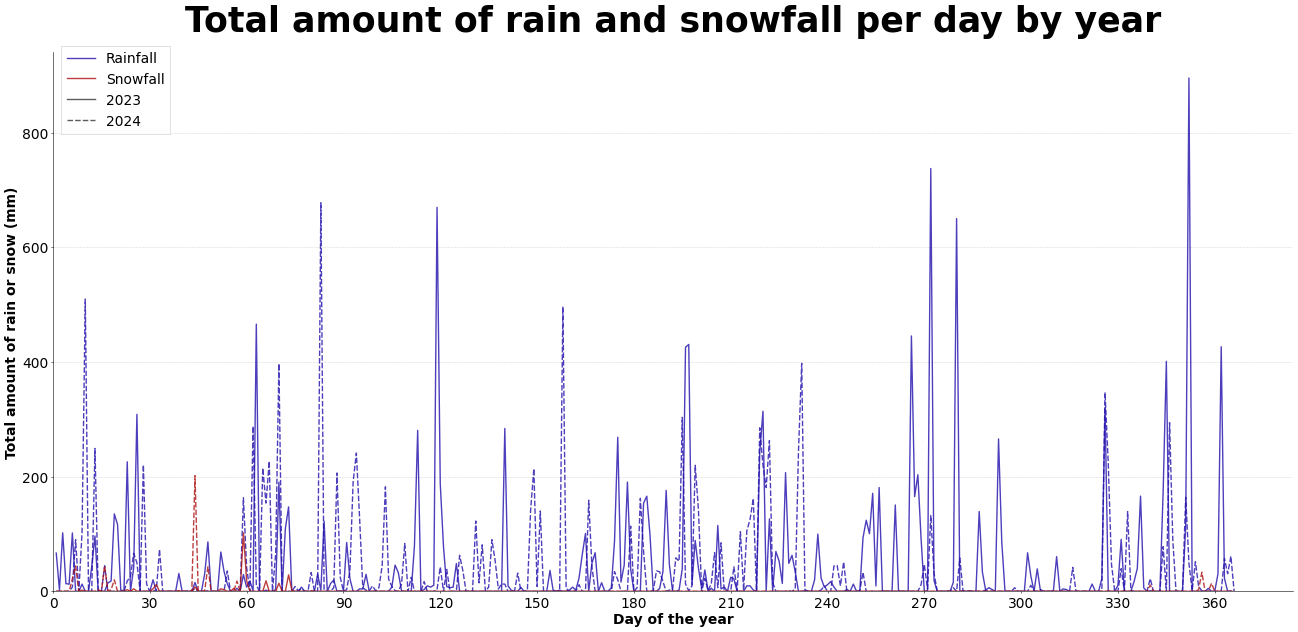

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# 1. Environmental Data Aggregation
# ---------------------------------------------------------
# Extract and aggregate the meteorological variables (rain and snowfall).
daily_weather = PUs_df.groupby("PUhour")[["rain", "snowfall"]].sum().reset_index()

# Extract the year and day of the year (1-365) to overlay the 2023 and 2024 
# weather patterns on a shared temporal x-axis.
daily_weather["year"] = daily_weather["PUhour"].dt.year
daily_weather["DayOfYear"] = daily_weather["PUhour"].dt.dayofyear

# ---------------------------------------------------------
# 2. Data Reshaping (Wide to Long Format)
# ---------------------------------------------------------
# Melt the dataframe to consolidate the rain and snow variables into a single column.
# This allows Seaborn to plot both meteorological metrics simultaneously 
# using the 'hue' parameter for color differentiation.
# (AI generated)
melted_weather = daily_weather.melt(
    id_vars=["PUhour", "year", "DayOfYear"],
    value_vars=["rain", "snowfall"],
    var_name="metric",
    value_name="amount"
)

# Standardize the metric nomenclature for presentation in the final legend
# (AI generated)
melted_weather["metric"] = melted_weather["metric"].replace({
    "rain": "Rainfall", 
    "snowfall": "Snowfall"
})

# ---------------------------------------------------------
# 3. Visualization Configuration
# ---------------------------------------------------------
palette = {
    "Rainfall": "#200EAC", # Dark Blue
    "Snowfall": "#AC0E0E", # Dark Red
}

plt.figure(figsize=(32, 14))

# Plot the weather trends. 
# 'hue' separates the metrics (rain vs snow) by color, while 'style' automatically 
# applies different line formatting (solid vs dashed) to differentiate 2023 and 2024.
ax = sns.lineplot(
    data=melted_weather,
    x="DayOfYear",
    y="amount",
    hue="metric",
    style="year",
    palette=palette,
    linewidth=2,
    alpha=0.8,
    errorbar=None
)

# ---------------------------------------------------------
# 4. Custom Legend Formatting
# ---------------------------------------------------------
# Seaborn automatically injects categorical group titles (like "year" or "metric") 
# into the legend when using hue and style. This loop strips those titles out 
# to maintain a clean, academic aesthetic.
handles, labels = ax.get_legend_handles_labels()        # AI generated
# AI generated:
new_handles = []
new_labels = []
# AI generated:
for handle, label in zip(handles, labels):
    if str(label).lower() not in ["year", "metric"]:  
        new_handles.append(handle)
        new_labels.append(label)

# Remove the default, unformatted legend
# (AI generated)
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Generate the cleaned legend outside the primary plotting area
ax.legend(
    handles=new_handles,
    labels=new_labels,
    loc="upper left",
    bbox_to_anchor=(0.001, 1.025),
    fancybox=False
)

# Configure plot aesthetics, titles, and gridlines
plt.title("Total amount of rain and snowfall per day by year",
          fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlabel("Day of the year", fontweight="bold")
plt.ylabel("Total amount of rain or snow (mm)", fontweight="bold")
plt.xticks(range(0, 366, 30))
plt.xlim(left=0)
plt.ylim(bottom=0)

# Export the high-resolution figure
#plt.savefig("Plots/TimeSeries/Weather/RainAndSnowDaily.png", dpi=300)
plt.show()

Apparent temperature and snow depth by day

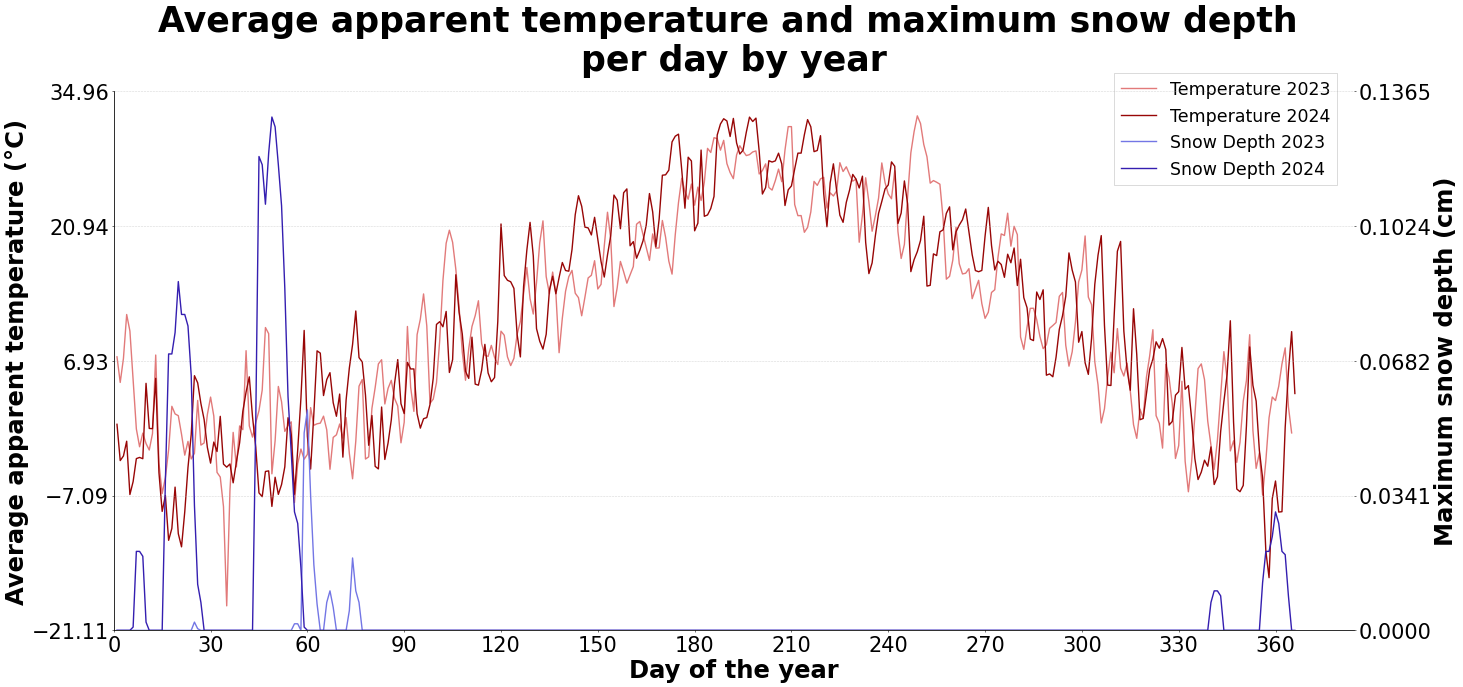

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# 1. Data Aggregation & Feature Extraction
# ---------------------------------------------------------
# Group the dataset by the timestamp column to aggregate daily weather metrics.
# Calculates the mean for apparent temperature and the maximum for snow depth.
# (AI generated)
daily_df = PUs_df.groupby("PUhour").agg({
    "apparent_temperature": "mean",
    "snow_depth": "max"
}).reset_index()

# Extract the year as a string for categorical grouping and 
# the numerical day of the year (1-365) for the x-axis.
daily_df["year"] = daily_df["PUhour"].dt.year.astype(str)
daily_df["DayOfYear"] = daily_df["PUhour"].dt.dayofyear

# Apply a 7-day rolling average to the apparent temperature, grouped by year.
# (AI generated)
daily_df["7DayTemp"] = daily_df.groupby("year")["apparent_temperature"].transform(
    lambda x: x.rolling(window=7).mean()
)

# ---------------------------------------------------------
# 2. Visualization: Primary Axis (Temperature)
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(32, 14))

# Plot the 7-day rolling average of temperature on the primary y-axis (ax1).
sns.lineplot(
    data=daily_df, 
    x="DayOfYear", 
    y="7DayTemp", 
    hue="year", 
    ax=ax1,
    palette={"2023": "#e27a7a", "2024": "#980606"}, # Light red for 2023, dark red for 2024
    linewidth=2,
    legend=False,
    errorbar=None 
)

# Format the primary y-axis and the shared x-axis.
plt.ylabel("Average apparent temperature (°C)", fontweight="bold", fontsize=35)
plt.xlabel("Day of the year", fontweight="bold", fontsize=35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlim(left=0)

# ---------------------------------------------------------
# 3. Visualization: Secondary Axis (Snow Depth)
# ---------------------------------------------------------
# Instantiate a second axes that shares the same x-axis.
# (AI generated)
ax2 = ax1.twinx()

# Plot the maximum snow depth on the secondary y-axis (ax2).
sns.lineplot(
    data=daily_df, 
    x="DayOfYear", 
    y="snow_depth", 
    hue="year", 
    ax=ax2,
    palette={"2023": "#7376e5", "2024": "#341eb0"}, # Light blue for 2023, dark blue for 2024
    linewidth=2,
    legend=False,
    errorbar=None 
)

# Format the secondary y-axis and overarching plot aesthetics.
plt.title("Average apparent temperature and maximum snow depth \nper day by year",
          fontsize=50, fontweight="bold", pad=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylabel("Maximum snow depth (cm)", fontweight="bold", fontsize=35)
plt.xticks(range(0, 366, 30), fontsize=30)
plt.yticks(fontsize=30)
plt.ylim(bottom=0)

# Synchronize the tick intervals between the primary and secondary y-axes
# by explicitly forcing both to render exactly 5 evenly spaced ticks.
# (AI generated)
ax1.yaxis.set_major_locator(ticker.LinearLocator(5))
ax2.yaxis.set_major_locator(ticker.LinearLocator(5))

# ---------------------------------------------------------
# 4. Custom Unified Legend
# ---------------------------------------------------------
# Manually construct legend handles (Line2D objects) to combine the items 
# from both ax1 (temperature) and ax2 (snow depth) into a single legend box.
# (AI generated)
custom_handles = [
    Line2D([0], [0], color="#e27a7a", lw=2),
    Line2D([0], [0], color="#980606", lw=2),
    Line2D([0], [0], color="#7376e5", lw=2),
    Line2D([0], [0], color="#341eb0", lw=2)
]

custom_labels = [
    "Temperature 2023",
    "Temperature 2024",
    "Snow Depth 2023",
    "Snow Depth 2024"
]

# Render the custom legend onto the primary axis.
ax1.legend(
    handles=custom_handles,
    labels=custom_labels,
    loc="upper left",
    bbox_to_anchor=(0.8, 1.05),
    fancybox=False,
    framealpha=1,
    fontsize=25
)

# Export as PDF.
#plt.savefig("Plots/TimeSeries/Weather/TempAndSnow_depthDaily.pdf", dpi=300, bbox_inches="tight")
plt.show()